# Step 10 - AIC and BIC Comparison

This notebook fits the shortlisted models and compares them with information criteria. The goal is to balance fit quality and parsimony before deciding which SARIMA specification should move into the deployment notebook.


In [1]:
import os
import time
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX

PROCESSED_PATH = "../data/processed/"
FIGURES_PATH = "../reports/figures/"
FIT_WINDOW_HOURS = 24 * 120

os.makedirs(FIGURES_PATH, exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")

series = pd.read_csv(
    os.path.join(PROCESSED_PATH, "pjme_imputed.csv"),
    parse_dates=["Datetime"],
    index_col="Datetime",
)["PJME_MW"].astype(float)

candidate_orders = pd.read_csv(
    os.path.join(PROCESSED_PATH, "sarima_candidate_orders.csv")
)

fit_series = series.iloc[-FIT_WINDOW_HOURS:]

print(f"Fit window: {fit_series.index.min()} to {fit_series.index.max()}")
print(f"Fit observations: {len(fit_series):,}")
display(candidate_orders)


Fit window: 2018-04-05 01:00:00 to 2018-08-03 00:00:00
Fit observations: 2,880


,label,p,d,q,P,D,Q,s,reason
0,arima_baseline_211,2,1,1,0,0,0,0,Non-seasonal benchmark using the strongest sho...
1,sarima_111_011_24,1,1,1,0,1,1,24,Parsimonious daily seasonal benchmark.
2,sarima_211_011_24,2,1,1,0,1,1,24,Adds one more non-seasonal AR lag suggested by...
3,sarima_121_011_24,1,1,2,0,1,1,24,Tests whether a second MA lag improves the sho...
4,sarima_111_111_24,1,1,1,1,1,1,24,Adds a seasonal AR term in case lag-24 persist...
5,sarima_211_111_24,2,1,1,1,1,1,24,Full low-order daily SARIMA candidate with bot...


In [2]:
fit_results = []


def fit_candidate(row: pd.Series) -> dict:
    order = (int(row["p"]), int(row["d"]), int(row["q"]))
    seasonal_order = (int(row["P"]), int(row["D"]), int(row["Q"]), int(row["s"]))
    start_time = time.perf_counter()

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        model = SARIMAX(
            fit_series,
            order=order,
            seasonal_order=seasonal_order,
            trend="n",
            enforce_stationarity=False,
            enforce_invertibility=False,
        )
        result = model.fit(disp=False)

    elapsed_seconds = time.perf_counter() - start_time
    lb_p_value = acorr_ljungbox(
        result.resid.dropna(), lags=[24], return_df=True
    )["lb_pvalue"].iloc[0]

    return {
        "label": row["label"],
        "order": str(order),
        "seasonal_order": str(seasonal_order),
        "aic": result.aic,
        "bic": result.bic,
        "hqic": result.hqic,
        "llf": result.llf,
        "n_params": result.params.shape[0],
        "ljung_box_pvalue_lag_24": lb_p_value,
        "fit_seconds": elapsed_seconds,
        "converged": bool(result.mle_retvals.get("converged", True)),
    }


for _, row in candidate_orders.iterrows():
    try:
        fit_results.append(fit_candidate(row))
    except Exception as exc:
        fit_results.append(
            {
                "label": row["label"],
                "order": str((int(row["p"]), int(row["d"]), int(row["q"]))),
                "seasonal_order": str(
                    (int(row["P"]), int(row["D"]), int(row["Q"]), int(row["s"]))
                ),
                "aic": float("nan"),
                "bic": float("nan"),
                "hqic": float("nan"),
                "llf": float("nan"),
                "n_params": float("nan"),
                "ljung_box_pvalue_lag_24": float("nan"),
                "fit_seconds": float("nan"),
                "converged": False,
                "error": str(exc),
            }
        )

results_df = pd.DataFrame(fit_results).sort_values(["bic", "aic"], ascending=True)
display(
    results_df.style.format(
        {
            "aic": "{:,.2f}",
            "bic": "{:,.2f}",
            "hqic": "{:,.2f}",
            "llf": "{:,.2f}",
            "ljung_box_pvalue_lag_24": "{:,.4f}",
            "fit_seconds": "{:,.2f}",
        }
    )
)


,label,order,seasonal_order,aic,bic,hqic,llf,n_params,ljung_box_pvalue_lag_24,fit_seconds,converged
5,sarima_211_111_24,"(2, 1, 1)","(1, 1, 1, 24)","39,924.97","39,960.66","39,937.85","-19,956.49",6,0.0000,12.11,True
4,sarima_111_111_24,"(1, 1, 1)","(1, 1, 1, 24)","39,966.36","39,996.10","39,977.09","-19,978.18",5,0.0000,9.33,True
3,sarima_121_011_24,"(1, 1, 2)","(0, 1, 1, 24)","40,062.57","40,092.31","40,073.30","-20,026.29",5,0.0000,7.25,True
2,sarima_211_011_24,"(2, 1, 1)","(0, 1, 1, 24)","40,090.78","40,120.52","40,101.51","-20,040.39",5,0.0000,8.59,True
1,sarima_111_011_24,"(1, 1, 1)","(0, 1, 1, 24)","40,123.69","40,147.48","40,132.27","-20,057.84",4,0.0000,6.55,True
0,arima_baseline_211,"(2, 1, 1)","(0, 0, 0, 0)","44,202.38","44,226.24","44,210.98","-22,097.19",4,0.0000,0.14,True


AIC and BIC reward good fit but penalize unnecessary complexity, so the best model is not always the one with the most parameters. In practice, the most useful candidate is often the one that keeps both information criteria low while also leaving less residual autocorrelation at the daily lag.


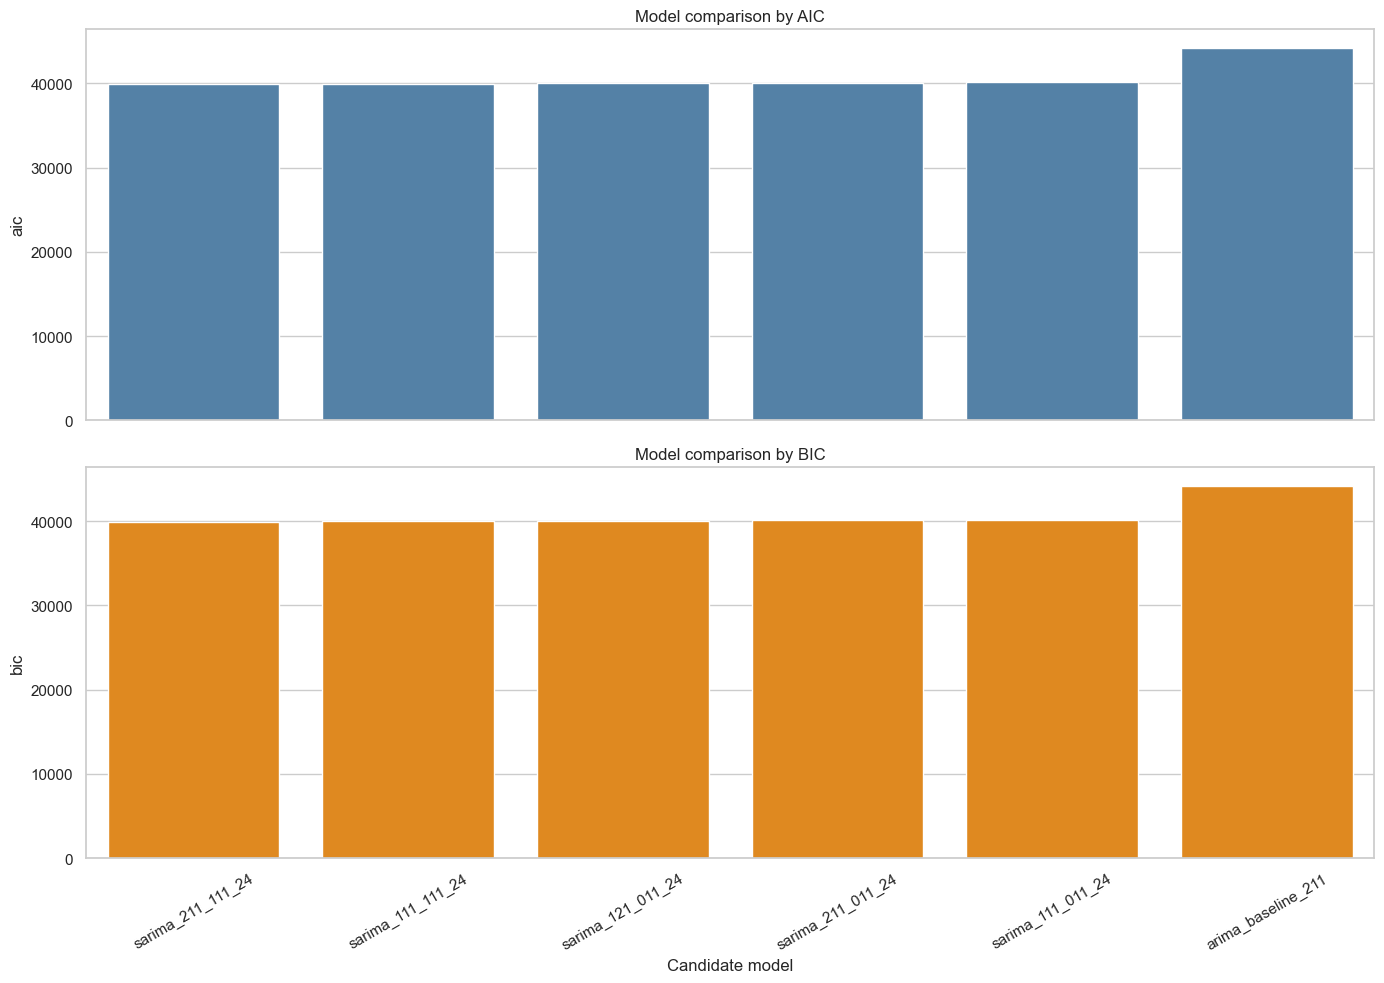

In [3]:
plot_df = results_df.dropna(subset=["aic", "bic"]).copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

sns.barplot(data=plot_df, x="label", y="aic", ax=axes[0], color="steelblue")
axes[0].set_title("Model comparison by AIC")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=plot_df, x="label", y="bic", ax=axes[1], color="darkorange")
axes[1].set_title("Model comparison by BIC")
axes[1].set_xlabel("Candidate model")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(
    os.path.join(FIGURES_PATH, "10_aic_bic_comparison.png"),
    dpi=150,
    bbox_inches="tight",
)
plt.show()


In [4]:
best_model = results_df.dropna(subset=["aic", "bic"]).iloc[0]

selected_model_summary = pd.DataFrame(
    [
        {
            "selected_label": best_model["label"],
            "selected_order": best_model["order"],
            "selected_seasonal_order": best_model["seasonal_order"],
            "selection_basis": "Lowest BIC, using AIC as a secondary tie-breaker.",
        }
    ]
)

results_df.to_csv(os.path.join(PROCESSED_PATH, "sarima_aic_bic_results.csv"), index=False)
selected_model_summary.to_csv(
    os.path.join(PROCESSED_PATH, "selected_sarima_model.csv"), index=False
)

print("Saved model comparison to ../data/processed/sarima_aic_bic_results.csv")
print("Saved selected model summary to ../data/processed/selected_sarima_model.csv")
selected_model_summary


Saved model comparison to ../data/processed/sarima_aic_bic_results.csv
Saved selected model summary to ../data/processed/selected_sarima_model.csv


,selected_label,selected_order,selected_seasonal_order,selection_basis
0,sarima_211_111_24,"(2, 1, 1)","(1, 1, 1, 24)","Lowest BIC, using AIC as a secondary tie-breaker."


Final decision: take the model with the best BIC among the converged candidates, then confirm in the next notebook that it can be fit cleanly on the final training data and used for repeatable forecasting. If AIC and BIC disagree, prefer the more parsimonious BIC winner unless diagnostics clearly show a worse residual pattern.
